# Ranking Sensitivity Analysis — LLM Causal Explanation Evaluation

> **C2 (Satisfaction) is excluded from the Likert data.** The active criteria are **C1, C3, C4, C5**.  
> Base AHP criterion weights are derived as the geometric mean across all 10 judge matrices, then renormalised over C1, C3, C4, C5.

This notebook runs four complementary ranking analyses:

| # | Method | What varies |
|---|--------|-------------|
| Base | AHP-weighted (C1, C3, C4, C5) | Geo-mean judge weights, renormalised |
| A1 | **Uniform criteria weights** | Equal weight (0.25) across C1, C3, C4, C5 |
| A2 | **Per-judge AHP weights (bootstrapped)** | Judge weights sampled; C2 dropped & renormalised per iteration |
| A3 | **Trustworthiness-only (C4)** | Single criterion, C4 weight = 1.0 |
| Stats | **Cross-method rank comparison** | Spearman ρ, Kendall τ, Borda scores, rank shift heatmap |

---
## Setup
Upload your files when prompted:
- `Final_Dataset___GT_Project_-_LikertScale.csv`
- `Final_Dataset___GT_Project_-_Criteria.csv`
- `Final_Dataset___GT_Project_-_Subcriteria.csv`


In [ ]:
# ── Install / import ──────────────────────────────────────────────
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scipy"])

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr, kendalltau
from itertools import combinations
warnings.filterwarnings('ignore')
print('Libraries ready.')

Libraries ready.


In [ ]:
# ════════════════════════════════════════════════════════════════
# SECTION 0 — LOAD & PARSE ALL DATA
# ════════════════════════════════════════════════════════════════

# ── 0.1  Likert evaluations ──────────────────────────────────────
# C2 (Satisfaction / S2.1, S2.2) columns are present in the file
# but excluded from all analyses. Active sub-criteria: S1, S3, S4, S5.
df = pd.read_csv('LikertScale.csv')

model_name_map = {
    'n': 'llama3.1:8b',
    'q': 'qwen2.5:7b',
    'm': 'mistral:7b',
    'c': 'codellama:7b',
    'p': 'phi3:3.8b',
    'x': 'mistral-nemo:12b',
    'z': 'qwen2.5:14b',
    'y': 'phi3:medium',
    'w': 'mixtral:8x7b'
}
df['Model'] = df['Model'].map(model_name_map)
models = sorted(df['Model'].unique())
print(f'Models ({len(models)}):', models)
print('All Likert columns in file:', [c for c in df.columns if c.startswith('S')])

# ── 0.2  AHP structure ───────────────────────────────────────────
# Active criteria: C1, C3, C4, C5  (C2 excluded by design)
#
# Base AHP weights derived as the geometric mean of per-judge weights
# across all 10 judges, then renormalised after dropping C2:
#   Geo-mean (5 criteria): C1=0.1076, C2=0.0849, C3=0.1411, C4=0.3787, C5=0.2877
#   After dropping C2 (sum of remainder = 0.9151), renormalised:
#     C1 = 0.1175,  C3 = 0.1542,  C4 = 0.4138,  C5 = 0.3144

CRITERIA       = ['C1', 'C3', 'C4', 'C5']
CRITERIA_NAMES = ['Understandability', 'Usefulness', 'Trustworthiness', 'Problem Solving']

criteria_structure = {
    'C1': ['S1.1', 'S1.2'],
    'C3': ['S3.1', 'S3.2'],
    'C4': ['S4.1', 'S4.2'],
    'C5': ['S5.1', 'S5.2'],
}

# Base weights: geo-mean across judges, renormalised without C2
BASE_CRITERION_WEIGHTS = {'C1': 0.1175, 'C3': 0.1542, 'C4': 0.4138, 'C5': 0.3144}

BASE_SUBCRITERION_WEIGHTS = {
    'S1.1': 0.7458, 'S1.2': 0.2542,
    'S3.1': 0.4856, 'S3.2': 0.5144,
    'S4.1': 0.7360, 'S4.2': 0.2640,
    'S5.1': 0.5000, 'S5.2': 0.5000,  # derived from judge data below; updated in cell 0.3
}

groups = {
    'G1': [5, 84, 70],
    'G2': [35, 105, 79],
    'G3': [99, 43, 45, 56],
    'G4': [75],
    'G5': [89]
}

LIKERT_MIN, LIKERT_MAX = 1, 5

def normalize_likert(x):
    return (x - LIKERT_MIN) / (LIKERT_MAX - LIKERT_MIN)

print('\nActive criteria (C2 excluded):', CRITERIA)
print('Base criterion weights:', BASE_CRITERION_WEIGHTS)
print('Groups:', {k: len(v) for k,v in groups.items()})


Models (9): ['codellama:7b', 'llama3.1:8b', 'mistral-nemo:12b', 'mistral:7b', 'mixtral:8x7b', 'phi3:3.8b', 'phi3:medium', 'qwen2.5:14b', 'qwen2.5:7b']
All Likert columns in file: ['S1.1', 'S1.2', 'S2.1', 'S2.2', 'S3.1', 'S3.2', 'S4.1', 'S4.2', 'S5.1', 'S5.2']

Active criteria (C2 excluded): ['C1', 'C3', 'C4', 'C5']
Base criterion weights: {'C1': 0.1175, 'C3': 0.1542, 'C4': 0.4138, 'C5': 0.3144}
Groups: {'G1': 3, 'G2': 3, 'G3': 4, 'G4': 1, 'G5': 1}


In [ ]:
# ── 0.3  Parse per-judge AHP matrices & derive S5 sub-weights ────

def parse_ahp_pairwise(raw_df, n_criteria=5):
    judges = {}
    current_judge = None
    current_rows = []
    for _, row in raw_df.iterrows():
        label = str(row.iloc[0]).strip()
        if label.startswith('J') and label[1:].isdigit():
            if current_judge and len(current_rows) == n_criteria:
                judges[current_judge] = np.array(current_rows, dtype=float)
            current_judge = label
            current_rows = []
        elif label in [f'C{i}' for i in range(1, n_criteria+1)]:
            vals = row.iloc[1:n_criteria+1].astype(float).tolist()
            current_rows.append(vals)
    if current_judge and len(current_rows) == n_criteria:
        judges[current_judge] = np.array(current_rows, dtype=float)
    return judges


def parse_subcriteria_pairwise(raw_df):
    result = {}
    current_key = None
    current_rows = []
    for _, row in raw_df.iterrows():
        label = str(row.iloc[0]).strip()
        if '/' in label and label != 'nan':
            if current_key and len(current_rows) == 2:
                result[current_key] = np.array(current_rows, dtype=float)
            current_key = label
            current_rows = []
        elif label.startswith('S') and len(label) == 4:
            vals = row.iloc[1:3].astype(float).tolist()
            current_rows.append(vals)
    if current_key and len(current_rows) == 2:
        result[current_key] = np.array(current_rows, dtype=float)
    return result


def ahp_weights_from_matrix(M):
    geo_means = np.exp(np.mean(np.log(np.clip(M, 1e-9, None)), axis=1))
    return geo_means / geo_means.sum()


def ahp_consistency_ratio(M, weights):
    n = M.shape[0]
    RI = {1:0, 2:0, 3:0.58, 4:0.90, 5:1.12, 6:1.24, 7:1.32, 8:1.41, 9:1.45}
    weighted_sum = M @ weights
    lambda_max = np.mean(weighted_sum / weights)
    CI = (lambda_max - n) / (n - 1) if n > 1 else 0
    ri = RI.get(n, 1.49)
    return CI / ri if ri > 0 else 0


raw_crit = pd.read_csv('Criteria.csv')
raw_sub  = pd.read_csv('Subcriteria.csv')

raw_crit_pos = raw_crit.copy(); raw_crit_pos.columns = range(raw_crit_pos.shape[1])
raw_sub_pos  = raw_sub.copy();  raw_sub_pos.columns  = range(raw_sub_pos.shape[1])

judge_crit_matrices = parse_ahp_pairwise(raw_crit_pos, n_criteria=5)
judge_sub_matrices  = parse_subcriteria_pairwise(raw_sub_pos)

print(f'Parsed {len(judge_crit_matrices)} judge criteria matrices.')
print(f'Parsed {len(judge_sub_matrices)} judge sub-criteria matrices.')

# Active criteria indices in the 5-dim weight vector: C1=0, C3=2, C4=3, C5=4  (C2=1 dropped)
ACTIVE_IDX       = [0, 2, 3, 4]
ACTIVE_CRIT_KEYS = ['C1', 'C3', 'C4', 'C5']

judge_criterion_weights = {}
judge_sub_weights       = {}
judge_cr = {}

for jid, M in judge_crit_matrices.items():
    w  = ahp_weights_from_matrix(M)
    cr = ahp_consistency_ratio(M, w)
    judge_cr[jid] = cr
    w_active = w[ACTIVE_IDX]
    w_active = w_active / w_active.sum()
    judge_criterion_weights[jid] = dict(zip(ACTIVE_CRIT_KEYS, w_active))

for key, M in judge_sub_matrices.items():
    jid, crit = key.split('/')
    if crit not in ACTIVE_CRIT_KEYS:   # skip C2
        continue
    w = ahp_weights_from_matrix(M)
    sub_keys = criteria_structure[crit]
    if jid not in judge_sub_weights:
        judge_sub_weights[jid] = {}
    judge_sub_weights[jid].update(dict(zip(sub_keys, w)))

# Derive base S5 sub-weights as geo-mean across judges
s5_w_list = []
for jid in judge_sub_weights:
    if 'S5.1' in judge_sub_weights[jid]:
        s5_w_list.append([judge_sub_weights[jid]['S5.1'], judge_sub_weights[jid]['S5.2']])

if s5_w_list:
    s5_arr = np.array(s5_w_list)
    s5_geo = np.exp(np.mean(np.log(np.clip(s5_arr, 1e-9, None)), axis=0))
    s5_geo = s5_geo / s5_geo.sum()
    BASE_SUBCRITERION_WEIGHTS['S5.1'] = round(float(s5_geo[0]), 4)
    BASE_SUBCRITERION_WEIGHTS['S5.2'] = round(float(s5_geo[1]), 4)
    print(f'\nDerived S5 base sub-weights from {len(s5_w_list)} judges:')
    print(f'  S5.1 = {BASE_SUBCRITERION_WEIGHTS["S5.1"]},  S5.2 = {BASE_SUBCRITERION_WEIGHTS["S5.2"]}')
else:
    print('\nWarning: no S5 sub-weights found in judge data; keeping default 0.5/0.5')

print('\nJudge consistency ratios (criteria level):')
for j, cr in sorted(judge_cr.items()):
    flag = '✓ consistent' if cr <= 0.10 else '✗ inconsistent'
    print(f'  {j}: CR = {cr:.3f}  {flag}')


Parsed 10 judge criteria matrices.
Parsed 49 judge sub-criteria matrices.

Derived S5 base sub-weights from 10 judges:
  S5.1 = 0.736,  S5.2 = 0.264

Judge consistency ratios (criteria level):
  J1: CR = 0.506  ✗ inconsistent
  J10: CR = 0.641  ✗ inconsistent
  J2: CR = 0.124  ✗ inconsistent
  J3: CR = 0.169  ✗ inconsistent
  J4: CR = 0.584  ✗ inconsistent
  J5: CR = 0.287  ✗ inconsistent
  J6: CR = 0.288  ✗ inconsistent
  J7: CR = 0.354  ✗ inconsistent
  J8: CR = 0.123  ✗ inconsistent
  J9: CR = 0.285  ✗ inconsistent


In [ ]:
# ════════════════════════════════════════════════════════════════
# SECTION 1 — CORE SCORING ENGINE
# Accepts arbitrary criterion_weights and subcriterion_weights.
# ════════════════════════════════════════════════════════════════

def compute_overall_score(df_input, models, groups, criteria,
                           criteria_structure, sub_w, crit_w):
    """
    Returns {model: score} using median IQR aggregation across groups.
    sub_w  : dict {Sx.x: weight}
    crit_w : dict {Cx: weight}
    """
    scores = {}
    for model in models:
        crit_scores = {}
        for crit in criteria:
            subs = criteria_structure[crit]
            group_medians = []
            for qlist in groups.values():
                subset = df_input[
                    (df_input['Model'] == model) &
                    (df_input['question_number'].isin(qlist))
                ]
                g_score = sum(
                    normalize_likert(subset[s].dropna().median()) * sub_w.get(s, 0)
                    for s in subs
                    if s in subset.columns and not subset[s].dropna().empty
                )
                group_medians.append(g_score)
            crit_scores[crit] = np.mean(group_medians)
        scores[model] = sum(crit_scores[c] * crit_w.get(c, 0) for c in criteria)
    return scores


def scores_to_ranks(scores):
    """Return {model: rank} with rank 1 = best."""
    return {
        m: r for m, r in zip(
            sorted(scores, key=scores.get, reverse=True),
            range(1, len(scores) + 1)
        )
    }


def bootstrap_ranking(df, models, groups, criteria, criteria_structure,
                       sub_w_fn, crit_w_fn,
                       n_bootstrap=2000, ci=0.95, seed=42):
    """
    Generic bootstrap for any scoring strategy.

    sub_w_fn(b)  : callable(iteration) -> subcriterion weight dict
    crit_w_fn(b) : callable(iteration) -> criterion weight dict

    Both callables receive the bootstrap iteration index so that
    weight-bootstrapping strategies can draw fresh samples each time.
    For fixed-weight scenarios they just return constants.

    Returns (boot_scores, boot_ranks, summary_df)
    """
    rng = np.random.default_rng(seed)
    boot_scores = {m: np.empty(n_bootstrap) for m in models}

    for b in range(n_bootstrap):
        # Resample rows within each (model, group) stratum
        chunks = []
        for model in models:
            for qlist in groups.values():
                chunk = df[
                    (df['Model'] == model) &
                    (df['question_number'].isin(qlist))
                ]
                if len(chunk) > 0:
                    chunks.append(
                        chunk.sample(n=len(chunk), replace=True,
                                     random_state=int(rng.integers(1e6)))
                    )
        df_boot = pd.concat(chunks, ignore_index=True)

        sub_w  = sub_w_fn(b)
        crit_w = crit_w_fn(b)

        iter_scores = compute_overall_score(
            df_boot, models, groups, criteria,
            criteria_structure, sub_w, crit_w
        )
        for m in models:
            boot_scores[m][b] = iter_scores[m]

    # Compute ranks per iteration
    score_matrix = np.column_stack([boot_scores[m] for m in models])
    rank_matrix  = np.argsort(np.argsort(-score_matrix, axis=1), axis=1) + 1
    boot_ranks   = {m: rank_matrix[:, i] for i, m in enumerate(models)}

    # Point estimates on original data
    # Use median weight draw for point estimate
    point_scores = compute_overall_score(
        df, models, groups, criteria, criteria_structure,
        sub_w_fn(0), crit_w_fn(0)
    )
    point_ranks = scores_to_ranks(point_scores)

    alpha = (1 - ci) / 2
    rows = []
    for m in models:
        s = boot_scores[m]
        r = boot_ranks[m]
        rows.append({
            'model':               m,
            'point_score':         round(point_scores[m], 4),
            'boot_score_mean':     round(np.mean(s), 4),
            'ci_lower':            round(np.quantile(s, alpha), 4),
            'ci_upper':            round(np.quantile(s, 1 - alpha), 4),
            'point_rank':          point_ranks[m],
            'median_rank':         round(float(np.median(r)), 1),
            'rank_ci_lower':       int(np.quantile(r, alpha)),
            'rank_ci_upper':       int(np.quantile(r, 1 - alpha)),
            'rank_stability_pct':  round(100 * np.mean(r == point_ranks[m]), 1),
        })

    summary = (
        pd.DataFrame(rows)
        .sort_values('point_rank')
        .reset_index(drop=True)
    )
    return boot_scores, boot_ranks, summary


print('Core engine ready.')

Core engine ready.


In [ ]:
# ════════════════════════════════════════════════════════════════
# SECTION 2 — SHARED PLOTTING HELPERS
# ════════════════════════════════════════════════════════════════

def plot_ci(summary, title, ax=None, color='#1f77b4'):
    """Horizontal CI plot for a single bootstrap summary."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 5))

    ordered = summary.sort_values('point_rank')
    y_pos   = np.arange(len(ordered))[::-1]

    for idx, (_, row) in enumerate(ordered.iterrows()):
        y = y_pos[idx]
        ax.errorbar(
            row['point_score'], y,
            xerr=[[row['point_score'] - row['ci_lower']],
                  [row['ci_upper']    - row['point_score']]],
            fmt='o', color=color, ecolor=color,
            elinewidth=2, capsize=5, capthick=1.5,
            markersize=7, alpha=0.8, zorder=3
        )
        ax.text(
            row['ci_upper'] + 0.003, y,
            f"#{int(row['point_rank'])}  (stab {row['rank_stability_pct']}%)",
            va='center', fontsize=8, color='#444'
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(ordered['model'].tolist(), fontsize=9)
    ax.set_xlabel('Weighted Composite Score (0–1)', fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    if standalone:
        plt.tight_layout()
        plt.show()


def plot_heatmap(boot_ranks, summary, title, ax=None):
    """Rank-frequency heatmap for a single bootstrap run."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 6))

    ordered_models = summary.sort_values('point_rank')['model'].tolist()
    n = len(ordered_models)
    freq = np.zeros((n, n))
    for i, m in enumerate(ordered_models):
        for j in range(1, n+1):
            freq[i, j-1] = np.mean(boot_ranks[m] == j) * 100

    im = ax.imshow(freq, cmap='Blues', aspect='auto', vmin=0, vmax=100)
    ax.set_xticks(range(n))
    ax.set_xticklabels([f'R{i+1}' for i in range(n)], rotation=45, fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(ordered_models, fontsize=8)
    for i in range(n):
        for j in range(n):
            tc = 'white' if freq[i,j] > 55 else '#333'
            ax.text(j, i, f'{freq[i,j]:.0f}%', ha='center', va='center',
                    fontsize=7, color=tc)
    plt.colorbar(im, ax=ax, label='% iterations')
    ax.set_title(title, fontsize=10)

    if standalone:
        plt.tight_layout()
        plt.show()


print('Plot helpers ready.')

Plot helpers ready.


---
## Base Analysis — Predefined AHP Weights (reference)

Running Base bootstrap (n=2000)…

=== Base Bootstrap Summary (predefined AHP weights) ===
           model  point_score  ci_lower  ci_upper  point_rank  median_rank  rank_stability_pct
     qwen2.5:14b       0.6552    0.5691    0.7634           1          1.0                89.3
      qwen2.5:7b       0.5451    0.4072    0.6776           2          2.0                47.6
     llama3.1:8b       0.4940    0.3857    0.5898           3          4.0                28.0
    mixtral:8x7b       0.4880    0.3240    0.5911           4          4.0                21.1
mistral-nemo:12b       0.4658    0.3409    0.5617           5          4.0                25.8
      mistral:7b       0.4043    0.2924    0.5557           6          6.0                34.2
       phi3:3.8b       0.3475    0.2090    0.3867           7          7.0                52.4
     phi3:medium       0.2819    0.1165    0.4685           8          8.0                48.0
    codellama:7b       0.1945    0.1313    0.2578      

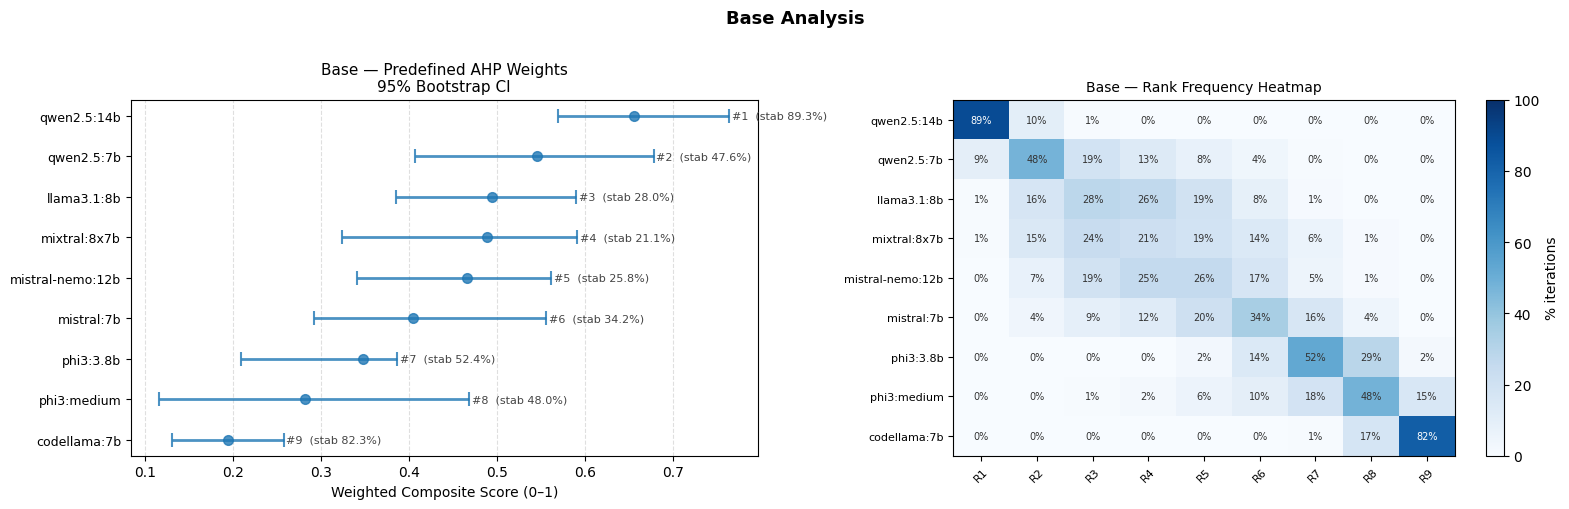

Saved base_bootstrap_summary.csv


In [ ]:
# ════════════════════════════════════════════════════════════════
# BASE — fixed AHP weights (Likert bootstrap only)
# ════════════════════════════════════════════════════════════════
print('Running Base bootstrap (n=2000)…')

base_scores, base_ranks, base_summary = bootstrap_ranking(
    df, models, groups, CRITERIA, criteria_structure,
    sub_w_fn  = lambda b: BASE_SUBCRITERION_WEIGHTS,
    crit_w_fn = lambda b: BASE_CRITERION_WEIGHTS,
    n_bootstrap=2000
)

print('\n=== Base Bootstrap Summary (predefined AHP weights) ===')
print(base_summary[['model','point_score','ci_lower','ci_upper',
                     'point_rank','median_rank','rank_stability_pct']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_ci(base_summary,
        'Base — Predefined AHP Weights\n95% Bootstrap CI', ax=axes[0])
plot_heatmap(base_ranks, base_summary,
             'Base — Rank Frequency Heatmap', ax=axes[1])
plt.suptitle('Base Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('base_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

base_summary.to_csv('base_bootstrap_summary.csv', index=False)
print('Saved base_bootstrap_summary.csv')

---
## Analysis 1 — Uniform Criteria Weights

Each criterion (C1–C4) receives equal weight = 0.25.  
Sub-criteria weights remain as the predefined AHP values.  
Likert rows are bootstrapped as in the base scenario.

Running A1 bootstrap (n=2000) — uniform weights (0.25 each) over C1, C3, C4, C5…

=== A1 Bootstrap Summary (uniform criteria weights, C2 excluded) ===
           model  point_score  ci_lower  ci_upper  point_rank  median_rank  rank_stability_pct
     qwen2.5:14b       0.6740    0.5785    0.7801           1          1.0                87.0
      qwen2.5:7b       0.5715    0.4434    0.7043           2          2.0                46.4
     llama3.1:8b       0.5351    0.4456    0.6313           3          3.0                37.8
mistral-nemo:12b       0.4858    0.3622    0.5858           4          4.0                27.4
    mixtral:8x7b       0.4718    0.3318    0.5811           5          5.0                26.8
      mistral:7b       0.4406    0.3199    0.6022           6          5.0                33.6
       phi3:3.8b       0.3467    0.2125    0.3971           7          7.0                54.2
     phi3:medium       0.2903    0.1282    0.4599           8          8.0               

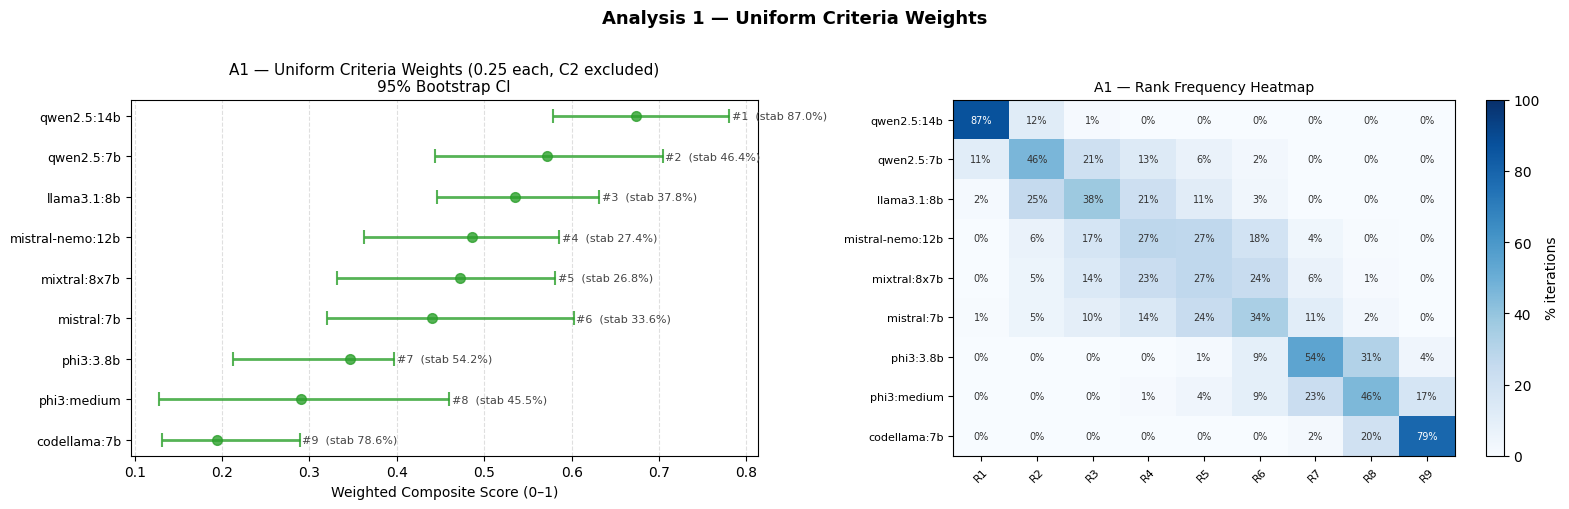

Saved a1_uniform_weights_summary.csv


In [11]:
# ════════════════════════════════════════════════════════════════
# ANALYSIS 1 — Uniform criteria weights
# C1 = C3 = C4 = C5 = 0.25  (C2 excluded)
# ════════════════════════════════════════════════════════════════
UNIFORM_CRITERION_WEIGHTS = {c: 0.25 for c in CRITERIA}

print('Running A1 bootstrap (n=2000) — uniform weights (0.25 each) over C1, C3, C4, C5…')

a1_scores, a1_ranks, a1_summary = bootstrap_ranking(
    df, models, groups, CRITERIA, criteria_structure,
    sub_w_fn  = lambda b: BASE_SUBCRITERION_WEIGHTS,
    crit_w_fn = lambda b: UNIFORM_CRITERION_WEIGHTS,
    n_bootstrap=2000
)

print('\n=== A1 Bootstrap Summary (uniform criteria weights, C2 excluded) ===')
print(a1_summary[['model','point_score','ci_lower','ci_upper',
                   'point_rank','median_rank','rank_stability_pct']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_ci(a1_summary,
        'A1 — Uniform Criteria Weights (0.25 each, C2 excluded)\n95% Bootstrap CI',
        ax=axes[0], color='#2ca02c')
plot_heatmap(a1_ranks, a1_summary, 'A1 — Rank Frequency Heatmap', ax=axes[1])
plt.suptitle('Analysis 1 — Uniform Criteria Weights', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('a1_uniform_weights_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

a1_summary.to_csv('a1_uniform_weights_summary.csv', index=False)
print('Saved a1_uniform_weights_summary.csv')


---
## Analysis 2 — Per-Judge AHP Weights (Bootstrapped)

Instead of using pre-aggregated weights, each bootstrap iteration:
1. Draws a judge at random (with replacement) from the pool of judges whose consistency ratio CR ≤ 0.10.
2. Uses that judge's AHP-derived criterion weights **and** sub-criterion weights.
3. Also resamples the Likert evaluation rows.

This propagates uncertainty in **both** the evaluation and the weighting stages.

Consistent judges (CR≤0.10): []
All judges available:        ['J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'J8', 'J9', 'J10']
Bootstrapping from ALL judges (shows instability from inconsistent judges).

Running A2 bootstrap (n=2000)…

=== A2 Bootstrap Summary (per-judge AHP weights, C2 excluded) ===
           model  point_score  ci_lower  ci_upper  point_rank  median_rank  rank_stability_pct
     qwen2.5:14b       0.6725    0.5714    0.7691           1          1.0                90.8
      qwen2.5:7b       0.5230    0.3904    0.6789           2          2.0                44.4
    mixtral:8x7b       0.4945    0.3199    0.5922           3          4.0                24.3
     llama3.1:8b       0.4888    0.3822    0.5914           4          4.0                26.6
mistral-nemo:12b       0.4810    0.3318    0.5663           5          4.0                25.8
      mistral:7b       0.4368    0.2861    0.5648           6          6.0                32.6
       phi3:3.8b       0.3495    0.21

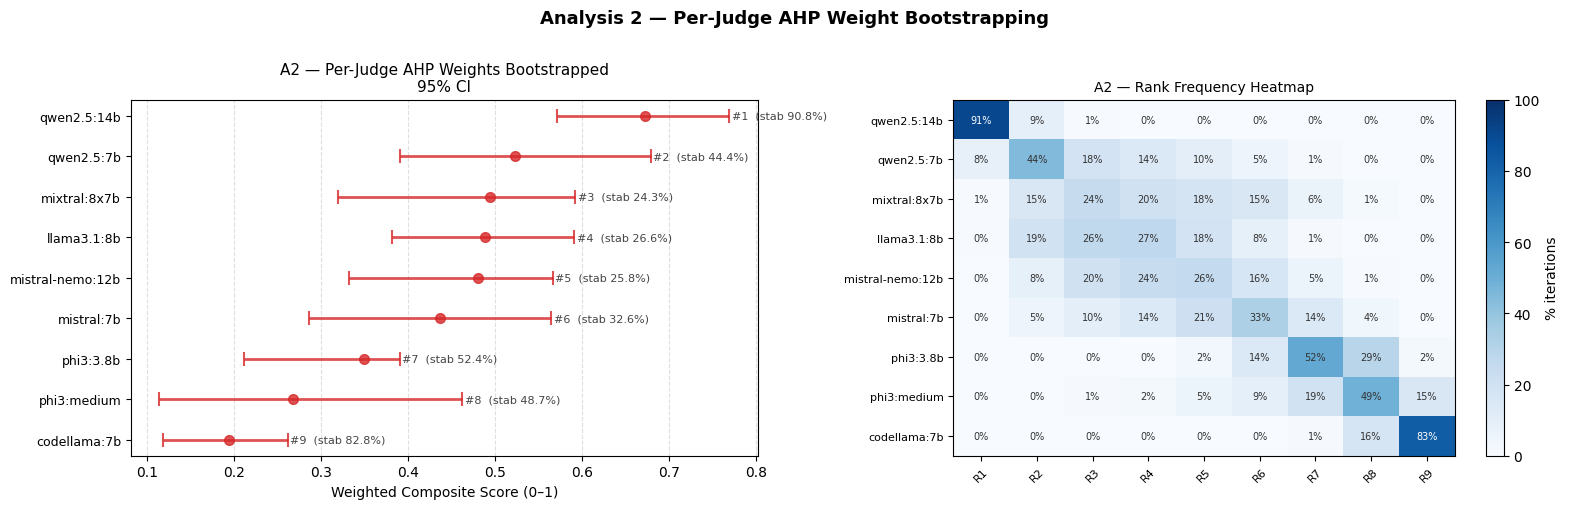

Saved a2_judge_weights_summary.csv


In [12]:
# ════════════════════════════════════════════════════════════════
# ANALYSIS 2 — Per-judge AHP weight bootstrapping
# Each iteration: draw a judge, use their C1/C3/C4/C5 weights
# (C2 dropped and renormalised per judge). Also resamples Likert rows.
# ════════════════════════════════════════════════════════════════

consistent_judges = [j for j, cr in judge_cr.items() if cr <= 0.10]
all_judges        = list(judge_criterion_weights.keys())

print(f'Consistent judges (CR≤0.10): {consistent_judges}')
print(f'All judges available:        {all_judges}')
print('Bootstrapping from ALL judges (shows instability from inconsistent judges).')

def get_judge_sub_w(jid):
    base = dict(BASE_SUBCRITERION_WEIGHTS)
    if jid in judge_sub_weights:
        base.update(judge_sub_weights[jid])
    return base

# Pre-generate judge sequence so crit_w and sub_w draw the same judge per iteration
a2_judge_seq = [
    all_judges[i % len(all_judges)]
    for i in np.random.default_rng(42).integers(0, len(all_judges), 2000)
]

def a2_crit_w(b):
    j = a2_judge_seq[b % len(a2_judge_seq)]
    return judge_criterion_weights.get(j, BASE_CRITERION_WEIGHTS)

def a2_sub_w(b):
    j = a2_judge_seq[b % len(a2_judge_seq)]
    return get_judge_sub_w(j)

print('\nRunning A2 bootstrap (n=2000)…')

a2_scores, a2_ranks, a2_summary = bootstrap_ranking(
    df, models, groups, CRITERIA, criteria_structure,
    sub_w_fn  = a2_sub_w,
    crit_w_fn = a2_crit_w,
    n_bootstrap=2000
)

print('\n=== A2 Bootstrap Summary (per-judge AHP weights, C2 excluded) ===')
print(a2_summary[['model','point_score','ci_lower','ci_upper',
                   'point_rank','median_rank','rank_stability_pct']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_ci(a2_summary,
        'A2 — Per-Judge AHP Weights Bootstrapped\n95% CI',
        ax=axes[0], color='#d62728')
plot_heatmap(a2_ranks, a2_summary, 'A2 — Rank Frequency Heatmap', ax=axes[1])
plt.suptitle('Analysis 2 — Per-Judge AHP Weight Bootstrapping', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('a2_judge_weights_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

a2_summary.to_csv('a2_judge_weights_summary.csv', index=False)
print('Saved a2_judge_weights_summary.csv')


---
## Analysis 3 — Trustworthiness Only (C4)

C4 (Trustworthiness) is the sole criterion: weight = 1.0.  
Its sub-criteria S4.1 and S4.2 use the predefined AHP sub-weights.  
This isolates how models rank on the single most operationally relevant dimension.

Running A3 bootstrap (n=2000) — Trustworthiness only…

=== A3 Bootstrap Summary (Trustworthiness only) ===
           model  point_score  ci_lower  ci_upper  point_rank  median_rank  rank_stability_pct
     qwen2.5:14b       0.6264    0.5500    0.7500           1          1.0                81.8
    mixtral:8x7b       0.5500    0.3000    0.6500           2          3.0                30.8
      qwen2.5:7b       0.4868    0.3868    0.6501           3          3.0                27.2
mistral-nemo:12b       0.4816    0.3500    0.5684           4          4.0                26.2
     llama3.1:8b       0.4316    0.3079    0.5685           5          5.0                22.5
      mistral:7b       0.3764    0.2868    0.5684           6          6.0                26.3
       phi3:3.8b       0.3500    0.2368    0.4000           7          7.0                45.6
     phi3:medium       0.2802    0.1000    0.4868           8          8.0                41.2
    codellama:7b       0.2368    0.150

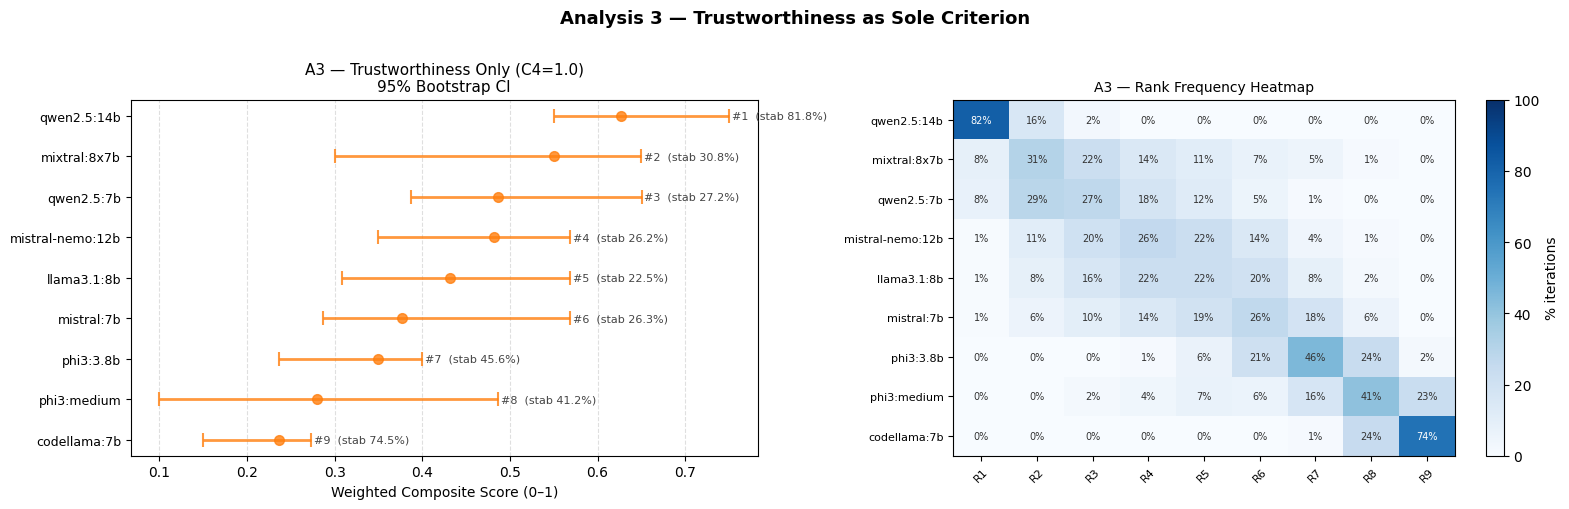

Saved a3_trustworthiness_summary.csv


In [13]:
# ════════════════════════════════════════════════════════════════
# ANALYSIS 3 — Trustworthiness only (C4 weight = 1.0)
# C2 excluded from all analyses.
# ════════════════════════════════════════════════════════════════
TRUST_CRITERION_WEIGHTS    = {'C1': 0.0, 'C3': 0.0, 'C4': 1.0, 'C5': 0.0}
TRUST_SUBCRITERION_WEIGHTS = dict(BASE_SUBCRITERION_WEIGHTS)

print('Running A3 bootstrap (n=2000) — Trustworthiness only…')

a3_scores, a3_ranks, a3_summary = bootstrap_ranking(
    df, models, groups, CRITERIA, criteria_structure,
    sub_w_fn  = lambda b: TRUST_SUBCRITERION_WEIGHTS,
    crit_w_fn = lambda b: TRUST_CRITERION_WEIGHTS,
    n_bootstrap=2000
)

print('\n=== A3 Bootstrap Summary (Trustworthiness only) ===')
print(a3_summary[['model','point_score','ci_lower','ci_upper',
                   'point_rank','median_rank','rank_stability_pct']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_ci(a3_summary,
        'A3 — Trustworthiness Only (C4=1.0)\n95% Bootstrap CI',
        ax=axes[0], color='#ff7f0e')
plot_heatmap(a3_ranks, a3_summary, 'A3 — Rank Frequency Heatmap', ax=axes[1])
plt.suptitle('Analysis 3 — Trustworthiness as Sole Criterion', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('a3_trustworthiness_only.png', dpi=150, bbox_inches='tight')
plt.show()

a3_summary.to_csv('a3_trustworthiness_summary.csv', index=False)
print('Saved a3_trustworthiness_summary.csv')


---
## Statistical Comparison — Cross-Method Rank Agreement

We compare all pairwise combinations of the four ranking methods using:

| Metric | What it measures |
|--------|------------------|
| **Spearman ρ** | Monotonic correlation of ranks |
| **Kendall τ** | Pairwise concordance of ranks |
| **Borda score overlap** | Agreement in top-K selections |
| **Rank shift table** | Per-model rank change across methods |

In [14]:
# ════════════════════════════════════════════════════════════════
# STATISTICAL COMPARISON — all pairwise method combinations
# ════════════════════════════════════════════════════════════════

METHOD_LABELS = ['Base (AHP)', 'A1 (Uniform)', 'A2 (Per-Judge)', 'A3 (Trust-Only)']
SUMMARIES     = [base_summary, a1_summary, a2_summary, a3_summary]

# Build a rank DataFrame: rows = models, cols = methods
rank_df = pd.DataFrame({'model': models}).set_index('model')
for label, summary in zip(METHOD_LABELS, SUMMARIES):
    rank_map = summary.set_index('model')['point_rank']
    rank_df[label] = rank_df.index.map(rank_map)

print('=== Point-Estimate Ranks by Method ===')
print(rank_df.sort_values('Base (AHP)').to_string())
rank_df.to_csv('rank_comparison_table.csv')
print('\nSaved rank_comparison_table.csv')

=== Point-Estimate Ranks by Method ===
                  Base (AHP)  A1 (Uniform)  A2 (Per-Judge)  A3 (Trust-Only)
model                                                                      
qwen2.5:14b                1             1               1                1
qwen2.5:7b                 2             2               2                3
llama3.1:8b                3             3               4                5
mixtral:8x7b               4             5               3                2
mistral-nemo:12b           5             4               5                4
mistral:7b                 6             6               6                6
phi3:3.8b                  7             7               7                7
phi3:medium                8             8               8                8
codellama:7b               9             9               9                9

Saved rank_comparison_table.csv



=== Spearman ρ (rank correlation) ===
                 Base (AHP)  A1 (Uniform)  A2 (Per-Judge)  A3 (Trust-Only)
Base (AHP)            1.000         0.983           0.983            0.917
A1 (Uniform)          0.983         1.000           0.950            0.883
A2 (Per-Judge)        0.983         0.950           1.000            0.967
A3 (Trust-Only)       0.917         0.883           0.967            1.000

=== Kendall τ (rank concordance) ===
                 Base (AHP)  A1 (Uniform)  A2 (Per-Judge)  A3 (Trust-Only)
Base (AHP)            1.000         0.944           0.944            0.833
A1 (Uniform)          0.944         1.000           0.889            0.778
A2 (Per-Judge)        0.944         0.889           1.000            0.889
A3 (Trust-Only)       0.833         0.778           0.889            1.000


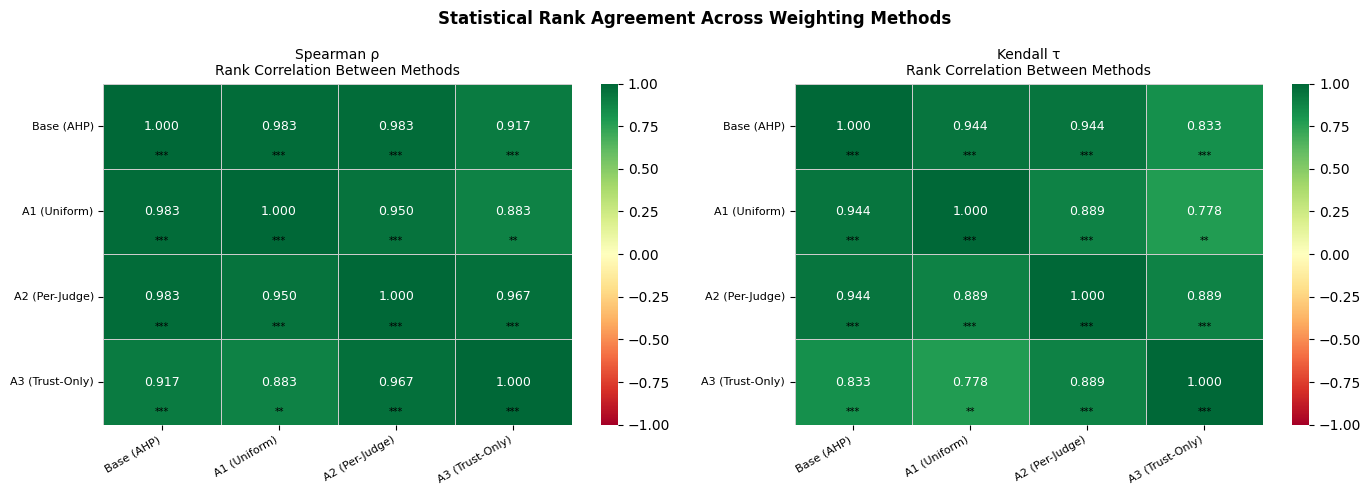

Saved rank_correlation_heatmaps.png, spearman_matrix.csv, kendall_matrix.csv


In [15]:
# ── Spearman ρ and Kendall τ matrices ───────────────────────────
n_methods = len(METHOD_LABELS)
spearman_mat = np.zeros((n_methods, n_methods))
kendall_mat  = np.zeros((n_methods, n_methods))
spearman_p   = np.zeros((n_methods, n_methods))
kendall_p    = np.zeros((n_methods, n_methods))

for i in range(n_methods):
    for j in range(n_methods):
        r1 = rank_df[METHOD_LABELS[i]].values
        r2 = rank_df[METHOD_LABELS[j]].values
        rho, p_s = spearmanr(r1, r2)
        tau, p_k = kendalltau(r1, r2)
        spearman_mat[i, j] = rho
        kendall_mat[i, j]  = tau
        spearman_p[i, j]   = p_s
        kendall_p[i, j]    = p_k

spearman_df = pd.DataFrame(spearman_mat, index=METHOD_LABELS, columns=METHOD_LABELS)
kendall_df  = pd.DataFrame(kendall_mat,  index=METHOD_LABELS, columns=METHOD_LABELS)

print('\n=== Spearman ρ (rank correlation) ===')
print(spearman_df.round(3).to_string())
print('\n=== Kendall τ (rank concordance) ===')
print(kendall_df.round(3).to_string())

# ── Heatmap figure ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title, pmat in [
    (axes[0], spearman_df, 'Spearman ρ', spearman_p),
    (axes[1], kendall_df,  'Kendall τ',  kendall_p)
]:
    sns.heatmap(
        mat, annot=True, fmt='.3f', cmap='RdYlGn',
        vmin=-1, vmax=1, ax=ax,
        annot_kws={'size': 9},
        linewidths=0.5, linecolor='#ccc'
    )
    ax.set_title(f'{title}\nRank Correlation Between Methods', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

    # Add p-value stars
    for i in range(n_methods):
        for j in range(n_methods):
            p = pmat[i, j]
            star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            if star:
                ax.text(j + 0.5, i + 0.85, star, ha='center', va='center',
                        fontsize=7, color='black')

plt.suptitle('Statistical Rank Agreement Across Weighting Methods',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('rank_correlation_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

spearman_df.round(4).to_csv('spearman_matrix.csv')
kendall_df.round(4).to_csv('kendall_matrix.csv')
print('Saved rank_correlation_heatmaps.png, spearman_matrix.csv, kendall_matrix.csv')

In [16]:
# ── Pairwise comparison table ─────────────────────────────────────
rows_pw = []
for (i, l1), (j, l2) in combinations(enumerate(METHOD_LABELS), 2):
    r1 = rank_df[l1].values
    r2 = rank_df[l2].values
    rho, p_s = spearmanr(r1, r2)
    tau, p_k = kendalltau(r1, r2)
    max_shift = int(np.max(np.abs(r1 - r2)))
    mean_shift = round(float(np.mean(np.abs(r1 - r2))), 2)
    rows_pw.append({
        'Method A':          l1,
        'Method B':          l2,
        'Spearman ρ':        round(rho, 4),
        'Spearman p':        round(p_s, 4),
        'Kendall τ':         round(tau, 4),
        'Kendall p':         round(p_k, 4),
        'Max |rank shift|':  max_shift,
        'Mean |rank shift|': mean_shift,
    })

pairwise_df = pd.DataFrame(rows_pw)
print('=== Pairwise Rank Agreement ===')
print(pairwise_df.to_string(index=False))
pairwise_df.to_csv('pairwise_rank_agreement.csv', index=False)
print('\nSaved pairwise_rank_agreement.csv')

=== Pairwise Rank Agreement ===
      Method A        Method B  Spearman ρ  Spearman p  Kendall τ  Kendall p  Max |rank shift|  Mean |rank shift|
    Base (AHP)    A1 (Uniform)      0.9833      0.0000     0.9444     0.0000                 1               0.22
    Base (AHP)  A2 (Per-Judge)      0.9833      0.0000     0.9444     0.0000                 1               0.22
    Base (AHP) A3 (Trust-Only)      0.9167      0.0005     0.8333     0.0009                 2               0.67
  A1 (Uniform)  A2 (Per-Judge)      0.9500      0.0001     0.8889     0.0002                 2               0.44
  A1 (Uniform) A3 (Trust-Only)      0.8833      0.0016     0.7778     0.0024                 3               0.67
A2 (Per-Judge) A3 (Trust-Only)      0.9667      0.0000     0.8889     0.0002                 1               0.44

Saved pairwise_rank_agreement.csv


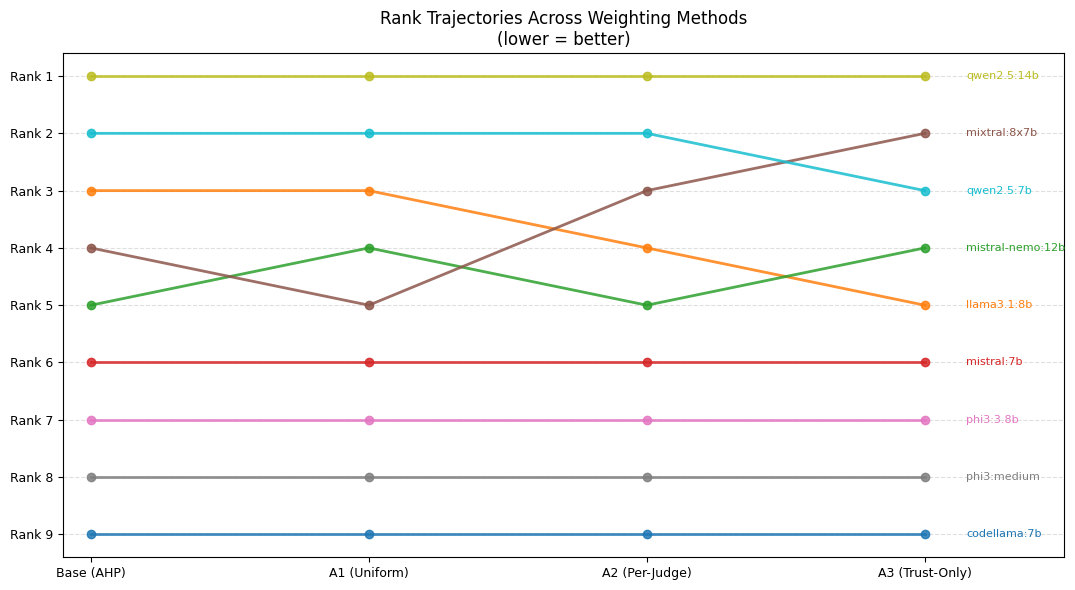

Saved bump_chart_ranks.png


In [17]:
# ── Bump chart — rank trajectories across methods ─────────────────
fig, ax = plt.subplots(figsize=(11, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
x_positions = range(len(METHOD_LABELS))

for m, color in zip(sorted(models), colors):
    y_vals = [rank_df.loc[m, lbl] for lbl in METHOD_LABELS]
    ax.plot(x_positions, y_vals, marker='o', linewidth=2,
            color=color, label=m, alpha=0.85)
    ax.text(len(METHOD_LABELS) - 0.85, y_vals[-1], m,
            va='center', fontsize=8, color=color)

ax.set_xticks(x_positions)
ax.set_xticklabels(METHOD_LABELS, fontsize=9)
ax.set_yticks(range(1, len(models) + 1))
ax.set_yticklabels([f'Rank {i}' for i in range(1, len(models) + 1)], fontsize=9)
ax.invert_yaxis()
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_xlim(-0.1, len(METHOD_LABELS) - 0.5)
ax.set_title('Rank Trajectories Across Weighting Methods\n(lower = better)', fontsize=12)

plt.tight_layout()
plt.savefig('bump_chart_ranks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved bump_chart_ranks.png')

=== Borda Aggregated Ranking (across all 4 methods) ===
           model  borda_score  borda_rank
     qwen2.5:14b           32           1
      qwen2.5:7b           27           2
    mixtral:8x7b           22           3
     llama3.1:8b           21           4
mistral-nemo:12b           18           5
      mistral:7b           12           6
       phi3:3.8b            8           7
     phi3:medium            4           8
    codellama:7b            0           9


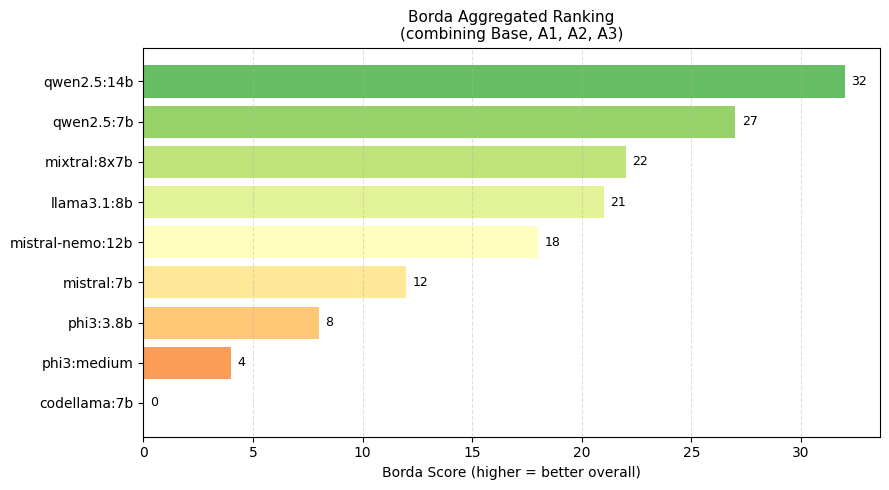

Saved borda_ranking.png, borda_aggregated_ranking.csv


In [18]:
# ── Borda count aggregated ranking ──────────────────────────────
# Borda: model gets (n_models - rank) points per method; sum across methods.
n_m = len(models)
borda = {m: 0 for m in models}
for lbl in METHOD_LABELS:
    for m in models:
        borda[m] += (n_m - rank_df.loc[m, lbl])

borda_df = (
    pd.DataFrame.from_dict(borda, orient='index', columns=['borda_score'])
    .sort_values('borda_score', ascending=False)
    .reset_index()
    .rename(columns={'index': 'model'})
)
borda_df['borda_rank'] = range(1, len(borda_df) + 1)

print('=== Borda Aggregated Ranking (across all 4 methods) ===')
print(borda_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    borda_df['model'], borda_df['borda_score'],
    color=plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(borda_df)))[::-1]
)
ax.invert_yaxis()
ax.set_xlabel('Borda Score (higher = better overall)', fontsize=10)
ax.set_title('Borda Aggregated Ranking\n(combining Base, A1, A2, A3)', fontsize=11)
for bar, score in zip(bars, borda_df['borda_score']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(score)), va='center', fontsize=9)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('borda_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

borda_df.to_csv('borda_aggregated_ranking.csv', index=False)
print('Saved borda_ranking.png, borda_aggregated_ranking.csv')

=== Per-Model Rank Shifts vs Base AHP ===
                  Base (AHP)  A1 (Uniform)  A2 (Per-Judge)  A3 (Trust-Only)  Δ vs Base (A1 (Uniform))  Δ vs Base (A2 (Per-Judge))  Δ vs Base (A3 (Trust-Only))
model                                                                                                                                                         
qwen2.5:14b                1             1               1                1                         0                           0                            0
qwen2.5:7b                 2             2               2                3                         0                           0                            1
llama3.1:8b                3             3               4                5                         0                           1                            2
mixtral:8x7b               4             5               3                2                         1                          -1                           -2
mist

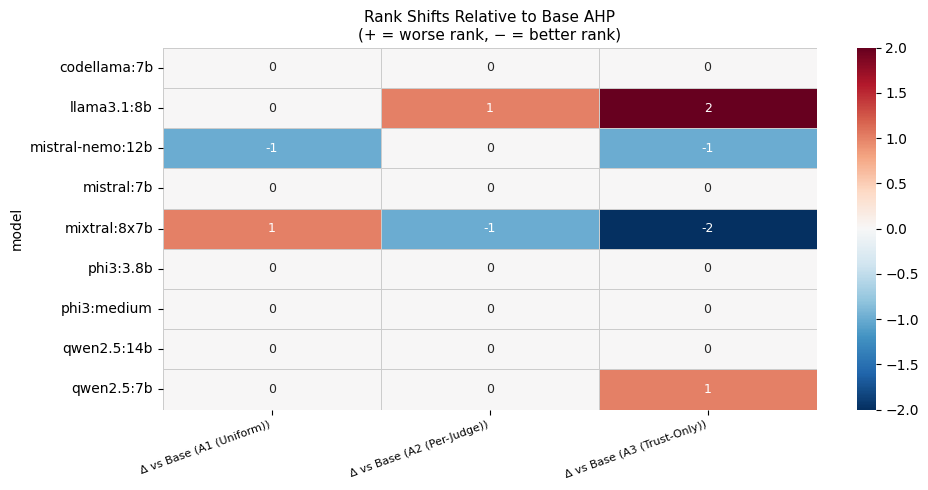

Saved rank_shift_heatmap.png, rank_shift_table.csv


In [19]:
# ── Per-model rank shift table ───────────────────────────────────
shift_df = rank_df.copy()
for lbl in METHOD_LABELS[1:]:
    shift_df[f'Δ vs Base ({lbl})'] = shift_df[lbl] - shift_df['Base (AHP)']

shift_cols = [c for c in shift_df.columns if c.startswith('Δ')]

print('=== Per-Model Rank Shifts vs Base AHP ===')
print(shift_df.sort_values('Base (AHP)')[METHOD_LABELS + shift_cols].to_string())

# Diverging heatmap of shifts
shift_only = shift_df[shift_cols]
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    shift_only, annot=True, fmt='.0f', cmap='RdBu_r',
    center=0, ax=ax, linewidths=0.5, linecolor='#ccc',
    annot_kws={'size': 9}
)
ax.set_title('Rank Shifts Relative to Base AHP\n(+ = worse rank, − = better rank)',
             fontsize=11)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('rank_shift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

shift_df.to_csv('rank_shift_table.csv')
print('Saved rank_shift_heatmap.png, rank_shift_table.csv')

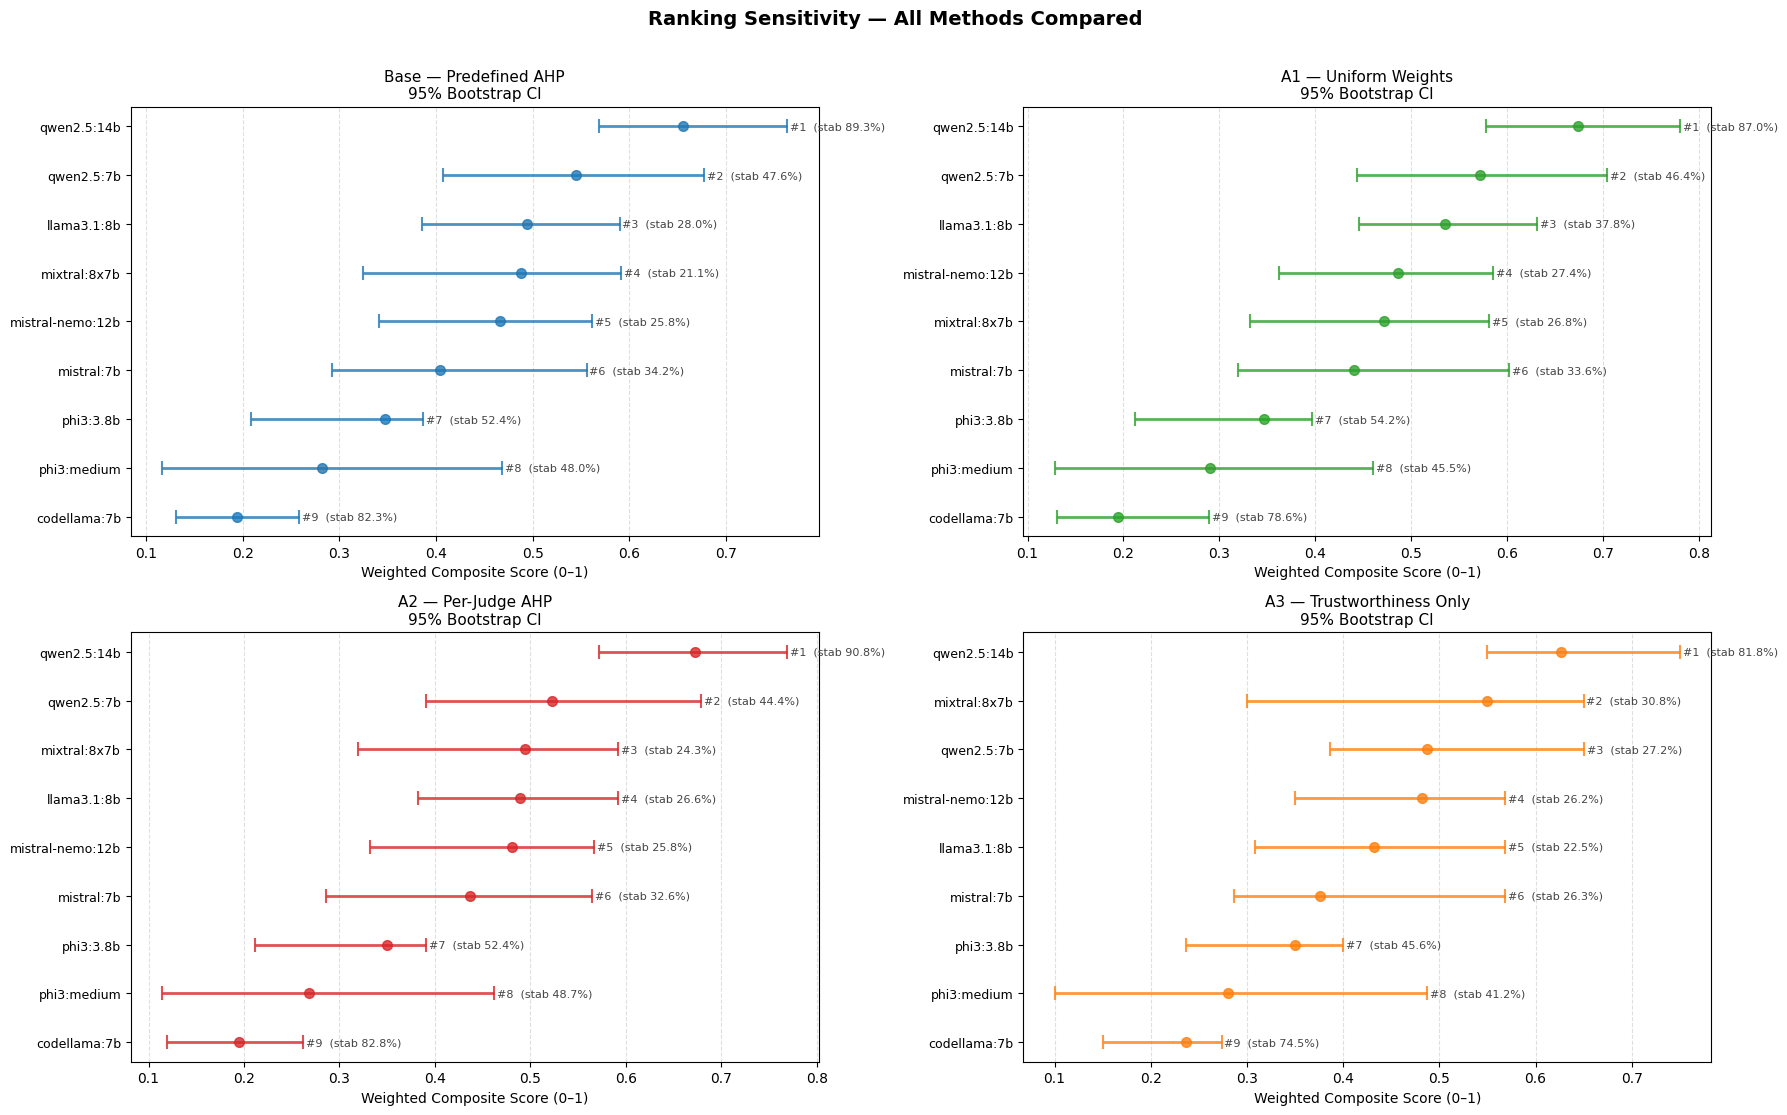

Saved all_methods_ci_panel.png


In [20]:
# ── Final 2×2 panel — CI plots for all methods ───────────────────
PALETTE = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e']
TITLES  = [
    'Base — Predefined AHP',
    'A1 — Uniform Weights',
    'A2 — Per-Judge AHP',
    'A3 — Trustworthiness Only'
]

fig, axes = plt.subplots(2, 2, figsize=(18, 11))
for ax, summary, title, color in zip(
    axes.flat, SUMMARIES, TITLES, PALETTE
):
    plot_ci(summary, title + '\n95% Bootstrap CI', ax=ax, color=color)

plt.suptitle('Ranking Sensitivity — All Methods Compared',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_methods_ci_panel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved all_methods_ci_panel.png')

In [21]:
# ── Final output summary ─────────────────────────────────────────
print('=' * 60)
print('ALL OUTPUT FILES')
print('=' * 60)
outputs = [
    ('base_bootstrap_summary.csv',     'Base AHP bootstrap ranks & CIs'),
    ('a1_uniform_weights_summary.csv', 'A1 uniform weight bootstrap'),
    ('a2_judge_weights_summary.csv',   'A2 per-judge AHP bootstrap'),
    ('a3_trustworthiness_summary.csv', 'A3 trustworthiness-only bootstrap'),
    ('rank_comparison_table.csv',      'Point-estimate ranks by method'),
    ('spearman_matrix.csv',            'Spearman ρ correlation matrix'),
    ('kendall_matrix.csv',             'Kendall τ correlation matrix'),
    ('pairwise_rank_agreement.csv',    'All pairwise Spearman/Kendall stats'),
    ('borda_aggregated_ranking.csv',   'Borda aggregated cross-method ranking'),
    ('rank_shift_table.csv',           'Per-model rank shifts vs Base'),
    ('base_bootstrap.png',             'Base CI + heatmap plots'),
    ('a1_uniform_weights_bootstrap.png','A1 CI + heatmap plots'),
    ('a2_judge_weights_bootstrap.png', 'A2 CI + heatmap plots'),
    ('a3_trustworthiness_only.png',    'A3 CI + heatmap plots'),
    ('rank_correlation_heatmaps.png',  'Spearman/Kendall heatmaps'),
    ('bump_chart_ranks.png',           'Rank trajectory bump chart'),
    ('borda_ranking.png',              'Borda bar chart'),
    ('rank_shift_heatmap.png',         'Per-model shift heatmap'),
    ('all_methods_ci_panel.png',       '2×2 CI panel — all methods'),
]
for fname, desc in outputs:
    exists = '✓' if os.path.exists(fname) else '✗'
    print(f'  {exists}  {fname:<42} {desc}')

ALL OUTPUT FILES
  ✓  base_bootstrap_summary.csv                 Base AHP bootstrap ranks & CIs
  ✓  a1_uniform_weights_summary.csv             A1 uniform weight bootstrap
  ✓  a2_judge_weights_summary.csv               A2 per-judge AHP bootstrap
  ✓  a3_trustworthiness_summary.csv             A3 trustworthiness-only bootstrap
  ✓  rank_comparison_table.csv                  Point-estimate ranks by method
  ✓  spearman_matrix.csv                        Spearman ρ correlation matrix
  ✓  kendall_matrix.csv                         Kendall τ correlation matrix
  ✓  pairwise_rank_agreement.csv                All pairwise Spearman/Kendall stats
  ✓  borda_aggregated_ranking.csv               Borda aggregated cross-method ranking
  ✓  rank_shift_table.csv                       Per-model rank shifts vs Base
  ✓  base_bootstrap.png                         Base CI + heatmap plots
  ✓  a1_uniform_weights_bootstrap.png           A1 CI + heatmap plots
  ✓  a2_judge_weights_bootstrap.png            